# Yeni Delhi Hava Tahmini - Prophet

In [1]:
#pip install prophet

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")

In [4]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
fig=px.line(df, x='date',y='meantemp')
fig.show()

In [6]:
fig=px.line(df, x='date',y='humidity')
fig.show()

In [7]:
fig=px.line(df, x='date',y='wind_speed')
fig.show()

In [8]:
fig=px.scatter(df, x='humidity',y='meantemp', trendline="ols")
fig.show()

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   str    
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.2 KB


In [10]:
df["date"] = pd.to_datetime(df["date"],format="%Y-%m-%d")

In [11]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month


In [12]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1


<Axes: xlabel='month', ylabel='meantemp'>

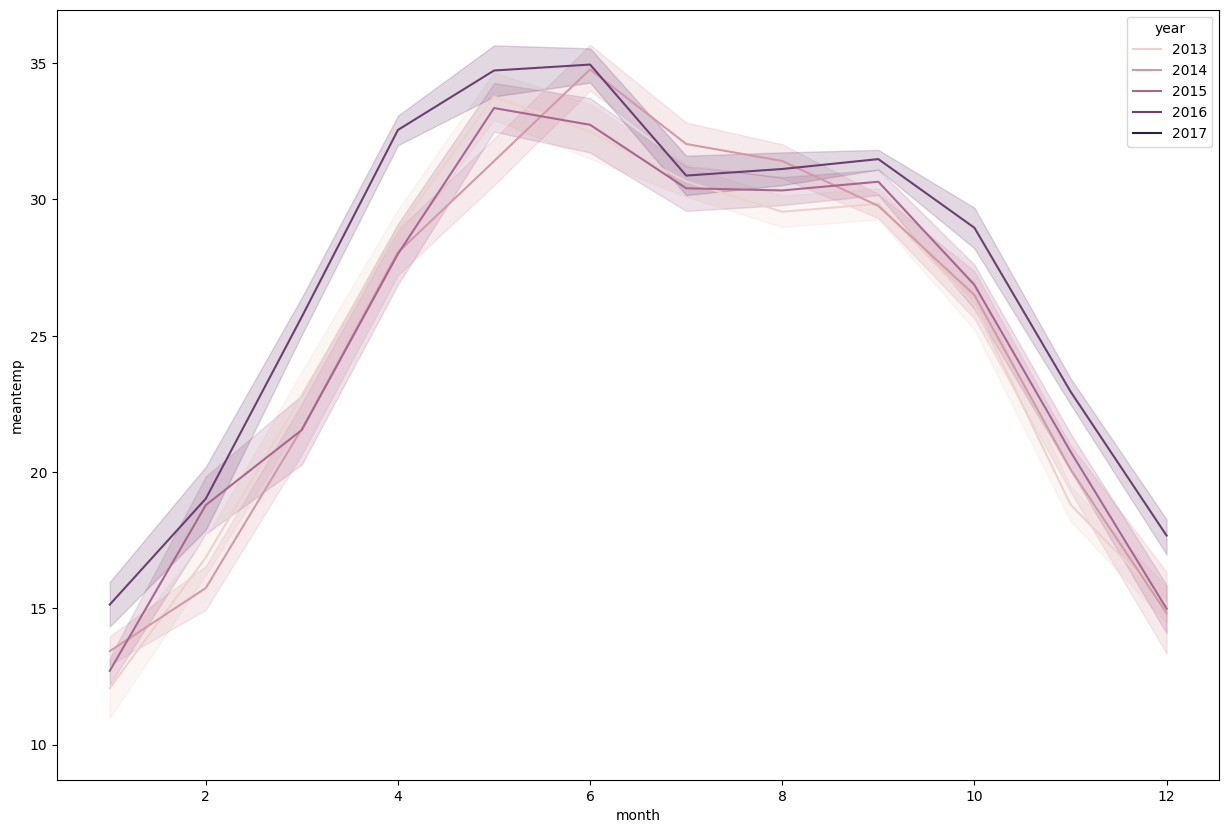

In [13]:
plt.figure(figsize=(15,10))
sns.lineplot(df,x = "month", y = "meantemp", hue="year")

In [14]:
forecast = df.rename(columns={"date":"ds", "meantemp" : "y"})

In [19]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

In [20]:
model = Prophet()


In [21]:
model.fit(forecast)

17:32:17 - cmdstanpy - INFO - Chain [1] start processing
17:32:17 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
tahmin = model.predict(forecast)

In [23]:
plot_plotly(model,tahmin)